### **👩‍🏫 👩🏿‍🏫 What You'll Learn**

- Comprehensive data analysis techniques using Python, Pandas, NumPy, and SciPy.
- Methods for data cleaning, exploratory analysis, statistical testing, and visualization.
- Insightful interpretation of complex datasets.

### **🛠️ What You Will Create**

- A thorough analysis of the "Airplane Crashes and Fatalities up to 2023" dataset, including detailed visualizations and statistical insights.

### **Objective**

- Utilize Python, Pandas, NumPy, and SciPy to conduct a thorough analysis of the "Airplane Crashes and Fatalities upto 2023" dataset. This challenge will encompass data cleaning, exploratory analysis, statistical testing, and visualization to draw meaningful insights.

### **Dataset**

- Work with the "Airplane Crashes and Fatalities upto 2023" dataset, which provides comprehensive details about airplane crashes, including dates, locations, fatalities, and more. Access the dataset here.

### **Tasks**

1. Data Import and Cleaning:
    - Import the dataset using Pandas.
    - Clean and preprocess the data, addressing missing values and categorizing data as needed.
    - Convert dates and other relevant fields to appropriate formats.
2. Exploratory Data Analysis:
    - Use Pandas to explore basic statistics such as the number of crashes, fatalities, and survival rates.
    - Analyze the frequency of crashes over time to identify any trends.
3. Statistical Analysis:
    - Apply SciPy to analyze the distribution of fatalities and survival rates. Calculate key statistics like mean, median, and standard deviation.
    - Conduct a hypothesis test (e.g., comparing the average number of fatalities in different decades or regions).
4. Visualization:
    - Create charts and graphs using Matplotlib and Seaborn to visualize the findings from your exploratory data analysis and statistical tests.
    - Examples might include time series plots of crashes over years, bar charts of crashes by region, and histograms of fatalities.
5. Insight and Report:
    - Summarize your findings and provide insights into the patterns or anomalies discovered in the data.
    - Prepare a well-structured report including all code, visualizations, and interpretations.

### **Submission**

- You should submit a comprehensive report encompassing their code, analysis, and visualizations. Articulate how you have applied NumPy, Pandas, and SciPy in your analysis, highlighting any significant patterns or insights discovered in the dataset.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv(
    "Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv", encoding="cp1252"
)

df.head()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [3]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum().sort_values(ascending=False))
print(df.isna().mean().sort_values(ascending=False) * 100)

(4998, 17)
Date                         str
Time                         str
Location                     str
Operator                     str
Flight #                     str
Route                        str
AC Type                      str
Registration                 str
cn/ln                        str
Aboard                   float64
Aboard Passangers        float64
Aboard Crew              float64
Fatalities               float64
Fatalities Passangers    float64
Fatalities Crew          float64
Ground                   float64
Summary                      str
dtype: object
Flight #                 3669
Time                     1512
Route                     777
cn/ln                     668
Registration              274
Fatalities Passangers     242
Fatalities Crew           241
Aboard Passangers         229
Aboard Crew               226
Summary                    64
Ground                     42
Aboard                     18
AC Type                    15
Operator                

In [4]:
# Parse dates - Date + Time are separate strings
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year
df["Decade"] = (df["Year"] // 10) * 10

df.head()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary,Year,Decade
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908,1900
1,1909-09-07,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...,1909,1900
2,1912-07-12,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912,1910
3,1913-08-06,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913,1910
4,1913-09-09,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...,1913,1910


In [5]:
# Fatalities / Aboard are the core numeric fields.
num_cols = ["Aboard", "Fatalities", "Ground"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with no date or no fatalities count - unusable for analysis.
df_clean = df.dropna(subset=["Date", "Fatalities"]).copy()

# Derived field used throughout survival rate per crash.
df_clean["Survivors"] = df_clean["Aboard"] - df_clean["Fatalities"]
df_clean["SurvivalRate"] = (df_clean["Survivors"] / df_clean["Aboard"]).clip(0, 1)

# Extract a rough region from location.
df_clean["Region"] = df_clean["Location"].str.split(",").str[-1].str.strip()

print(df_clean.shape)
df_clean.head()

(4990, 22)


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,...,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary,Year,Decade,Survivors,SurvivalRate,Region
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,...,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908,1900,1.0,0.5,Virginia
1,1909-09-07,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,...,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...,1909,1900,0.0,0.0,France
2,1912-07-12,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,...,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912,1910,0.0,0.0,New Jersey
3,1913-08-06,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,...,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913,1910,0.0,0.0,Canada
4,1913-09-09,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,...,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...,1913,1910,6.0,0.3,Over the North Sea


In [6]:
print("Total crashes:", len(df_clean))
print("Total fatalities:", df_clean["Fatalities"].sum())
print("Total aboard:", df_clean["Aboard"].sum())
print(
    "Overall survival rate: {:.1%}".format(
        df_clean["Survivors"].sum() / df_clean["Aboard"].sum()
    )
)
print("\nCrashes per decade:")
print(df_clean.groupby("Decade").size())

Total crashes: 4990
Total fatalities: 111644.0
Total aboard: 155356.0
Overall survival rate: 28.2%

Crashes per decade:
Decade
1900      2
1910     31
1920    181
1930    354
1940    575
1950    648
1960    636
1970    612
1980    552
1990    631
2000    506
2010    235
2020     27
dtype: int64


In [7]:
crashes_per_year = df_clean.groupby("Year").size()
fatalities_per_year = df_clean.groupby("Year")["Fatalities"].sum()

trend = pd.DataFrame({"crashes": crashes_per_year, "fatalities": fatalities_per_year})

trend["crashes_moving_average_5"] = (
    trend["crashes"].rolling(5, min_periods=1).mean()
)  # 5-year moving average to smooth the noise.
trend.tail(15)

,crashes,fatalities,crashes_moving_average_5
Year,,,
2009,46,1083.0,44.4
2010,40,1044.0,43.4
2011,36,720.0,43.0
2012,26,587.0,39.6
2013,25,287.0,34.6
2014,23,1142.0,30.0
2015,18,759.0,25.6
2016,23,515.0,23.0
2017,15,210.0,20.8


In [8]:
fat = df_clean["Fatalities"]
print(f"Mean: {fat.mean()}, Median: {fat.median()}, Std: {fat.std()}")
print(f"Skew: {fat.skew()}")

Mean: 22.37354709418838, Median: 11.0, Std: 35.06174065974316
Skew: 4.6074167630812495


In [9]:
# IQR outlier check.
Q1, Q3 = fat.quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_clean[fat > Q3 + 1.5 * IQR]
print(f"Outlier crashes (> 1.5 * IQR): {len(outliers)}")

Outlier crashes (> 1.5 * IQR): 455


In [10]:
early = df_clean[df_clean["Decade"] == 1990]["Fatalities"]
late = df_clean[df_clean["Decade"] == 2010]["Fatalities"]

stat, p = stats.mannwhitneyu(early, late, alternative="two-sided")
print(f"Mann-Whitney U: stat={stat:.1f}, p={p:.4f}")
print(f"Median 1990s: {early.median()}, Median 2010s: {late.median()}")
if p < 0.05:
    print("Statistically significant difference between decades fatality distributions")
else:
    print("No significant difference detected")

Mann-Whitney U: stat=72786.0, p=0.6784
Median 1990s: 10.0, Median 2010s: 10.0
No significant difference detected


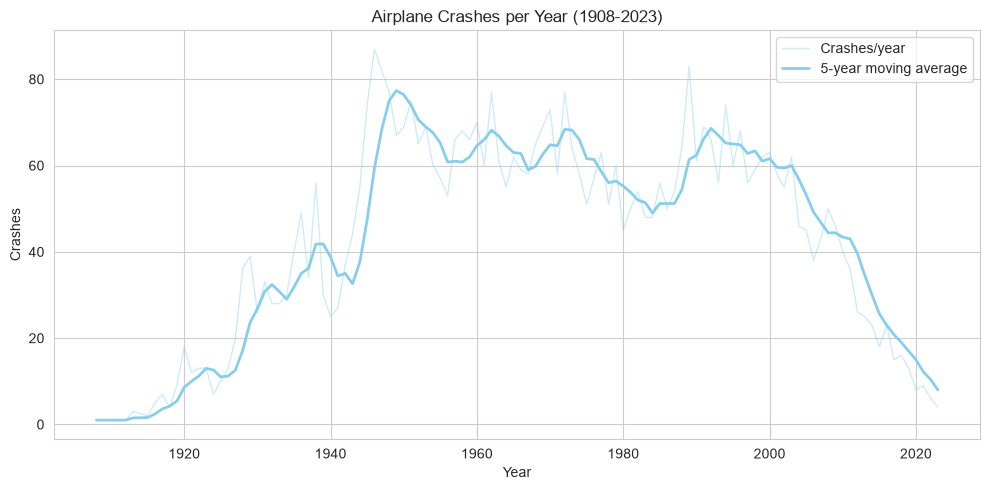

In [11]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    trend.index,
    trend["crashes"],
    color="skyblue",
    linewidth=1,
    alpha=0.4,
    label="Crashes/year",
)
ax.plot(
    trend.index,
    trend["crashes_moving_average_5"],
    color="skyblue",
    linewidth=2,
    label="5-year moving average",
)
ax.set_title("Airplane Crashes per Year (1908-2023)")
ax.set_xlabel("Year")
ax.set_ylabel("Crashes")
ax.legend()
plt.tight_layout()
plt.show()

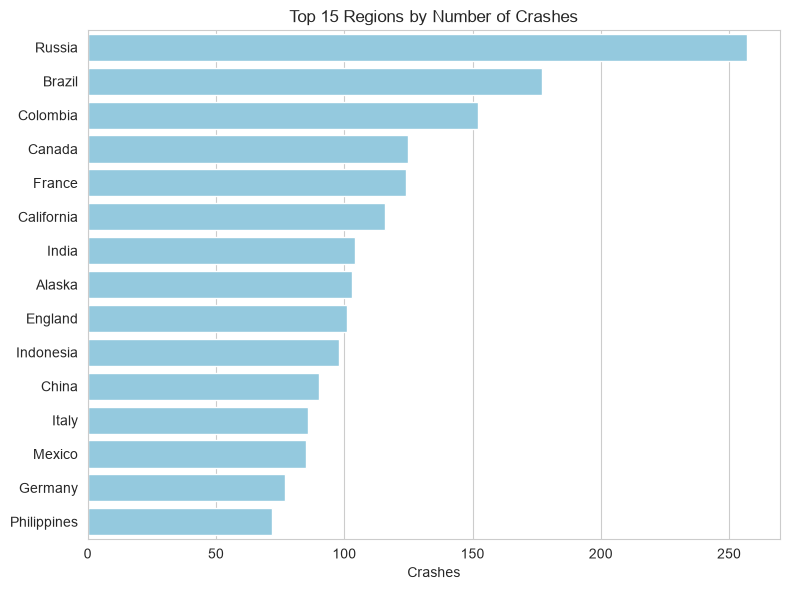

In [12]:
top_regions = df_clean["Region"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_regions.values, y=top_regions.index, ax=ax, color="skyblue")
ax.set_title("Top 15 Regions by Number of Crashes")
ax.set_xlabel("Crashes")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

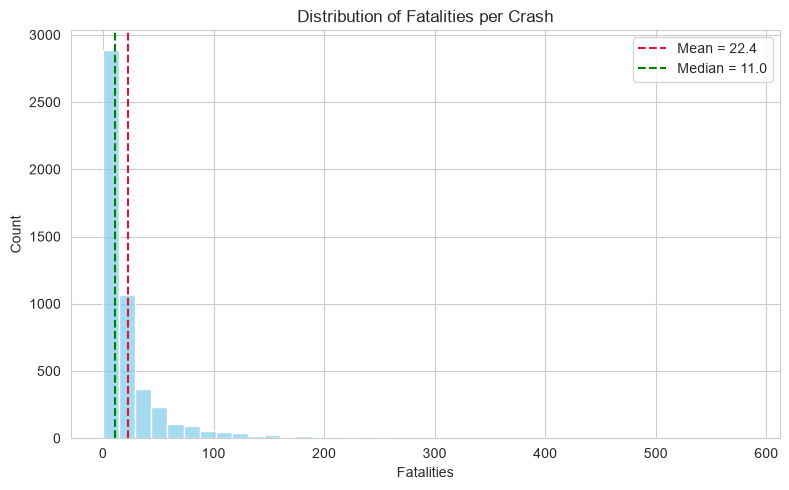

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_clean["Fatalities"], bins=40, color="skyblue", ax=ax)
ax.axvline(
    fat.mean(), color="crimson", linestyle="--", label=f"Mean = {fat.mean():.1f}"
)
ax.axvline(
    fat.median(), color="green", linestyle="--", label=f"Median = {fat.median():.1f}"
)
ax.set_title("Distribution of Fatalities per Crash")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Sanity check: does per-decade grouping match the raw counts?
assert df_clean.groupby("Decade").size().sum() == len(df_clean)

# Sanity check: survival rate should never exceed 1 or go negative
# (SurvivalRate is legitimately NaN for rows where Aboard is unknown or 0 - excluded, not an error)
valid_rate = df_clean["SurvivalRate"].dropna()
assert valid_rate.between(0, 1).all()

print(
    f"Sanity checks passed ({df_clean['SurvivalRate'].isna().sum()} rows have undefined SurvivalRate - Aboard missing or 0)."
)

Sanity checks passed (15 rows have undefined SurvivalRate - Aboard missing or 0).


## Findings

- **Volume trend**: Crashes rose steadily from the 1910s, peaked in the **1950s (648 crashes)**,
  then declined fairly steadily after the 1980s down to 235 in the 2010s (2020s figures are
  partial, since the dataset ends in 2023) - likely reflecting aviation safety improvements,
  not reduced air traffic.
- **Fatalities are heavily right-skewed** (mean ≈ **22.4** vs. median ≈ **11.0**, skew ≈ 4.6):
  most crashes have relatively few fatalities, but a small number of large-scale disasters pull
  the mean up well above the typical case. An IQR-based check flags **455 crashes (~9%)** as
  statistical outliers on fatality count.
- **Decade comparison**: A Mann-Whitney U test found **no statistically significant difference**
  in fatality distribution between the 1990s and 2010s (p = **0.68**), with median fatalities
  unchanged at **10** in both decades - crashes got much rarer over that period, but the ones
  that happened were not meaningfully less severe.
- **Regional concentration**: **Russia** accounts for the largest share of recorded crashes (257),
  followed by Brazil (177), Colombia (152), Canada (125), and France (124). This may partly
  reflect reporting/data-availability bias and geography (large countries with extensive small-aircraft
  and remote-area operations) rather than true per-flight risk concentration.

## Caveats

- Fatality counts have **0.16%** missing data in the raw file; rows missing Date or Fatalities
  were dropped before analysis (4998 → 4990 rows).
- **15 rows** have an undefined SurvivalRate (Aboard unknown or recorded as 0) and were excluded
  from that specific metric, not from the dataset as a whole.
- "Region" is derived from the last comma-separated token of the free-text Location field, so it
  mixes countries and U.S./Canadian states/provinces rather than being a clean region taxonomy.
